In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset (1).csv")

# Identify missing values in each column
missing_counts = df.isnull().sum()

# Calculate percentage of missing data
missing_percentage = (missing_counts / len(df)) * 100

# Combine results into a summary table
missing_summary = pd.DataFrame({
    "Missing Values": missing_counts,
    "Percentage (%)": missing_percentage.round(2)
})

print(missing_summary)

                    Missing Values  Percentage (%)
Patient_ID                       0            0.00
Age                            600           11.76
Gender                           0            0.00
City                             0            0.00
Diagnosis                        0            0.00
Hospital_Visits                  0            0.00
Treatment_Cost                 593           11.63
Insurance_Coverage               0            0.00
Admission_Date                   0            0.00


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset (1).csv")

# Check missing values in Age
print("Missing Age count:", df['Age'].isnull().sum())

# Option 1: Replace with Mean
df['Age_mean_filled'] = df['Age'].fillna(df['Age'].mean())

# Option 2: Replace with Median
df['Age_median_filled'] = df['Age'].fillna(df['Age'].median())

# Compare mean vs median
print("Mean Age:", df['Age'].mean())
print("Median Age:", df['Age'].median())


Missing Age count: 600
Mean Age: 49.59755555555556
Median Age: 50.0


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset (1).csv")

# Check missing values in Treatment_Cost
print("Missing Treatment_Cost count:", df['Treatment_Cost'].isnull().sum())

# Since Treatment_Cost is highly skewed, use Median imputation
df['Treatment_Cost_filled'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())

# Compare mean vs median
print("Mean Treatment Cost:", df['Treatment_Cost'].mean())
print("Median Treatment Cost:", df['Treatment_Cost'].median())


Missing Treatment_Cost count: 593
Mean Treatment Cost: 26920.151157458764
Median Treatment Cost: 24797.0


In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset (1).csv")

# Step 1: Identify duplicate rows
duplicates = df[df.duplicated()]
print("Number of duplicate rows:", duplicates.shape[0])

# Step 2: Remove duplicates
df_cleaned = df.drop_duplicates()

# Step 3: Compare dataset size before and after
print("Original dataset size:", df.shape[0])
print("Cleaned dataset size:", df_cleaned.shape[0])
print("Rows removed:", df.shape[0] - df_cleaned.shape[0])


Number of duplicate rows: 99
Original dataset size: 5100
Cleaned dataset size: 5001
Rows removed: 99


In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset (1).csv")

# Step 1: Detect invalid ages (<0 or >100)
invalid_age_records = df[(df['Age'] < 0) | (df['Age'] > 100)]
print("Invalid Age Records:")
print(invalid_age_records[['Patient_ID','Age']])

# Step 2: Decide whether to remove or correct
# Option A: Remove invalid records
df_removed = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

# Option B: Correct invalid ages (replace with median)
median_age = df['Age'].median()
df_corrected = df.copy()
df_corrected.loc[(df_corrected['Age'] < 0) | (df_corrected['Age'] > 100), 'Age'] = median_age

# Compare dataset sizes
print("Original dataset size:", df.shape[0])
print("After removing invalid ages:", df_removed.shape[0])
print("After correcting invalid ages:", df_corrected.shape[0])


Invalid Age Records:
Empty DataFrame
Columns: [Patient_ID, Age]
Index: []
Original dataset size: 5100
After removing invalid ages: 4500
After correcting invalid ages: 5100


In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset (1).csv")

# Step 1: Calculate Q1, Q3 and IQR
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Detect outliers
outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]

# Step 4: Display results
print("Number of outliers detected:", outliers.shape[0])
print("Outlier Treatment Costs:")
print(outliers[['Patient_ID','Treatment_Cost']])


Number of outliers detected: 50
Outlier Treatment Costs:
      Patient_ID  Treatment_Cost
53         13152   199702.965333
86         10064   199702.965333
124        17035   199702.965333
183        15855   199702.965333
215        19561   199702.965333
332        11686   199702.965333
382        10876   199702.965333
416        14070   199702.965333
452        10851   199702.965333
796        18150   199702.965333
833        19361   199702.965333
1127       10943   199702.965333
1176       18232   199702.965333
1219       15408   199702.965333
1392       14876   199702.965333
1613       16090   199702.965333
1729       10575   199702.965333
1771       15342   199702.965333
2077       11048   199702.965333
2166       10593   199702.965333
2210       12711   199702.965333
2228       18551   199702.965333
2382       10830   199702.965333
2449       10204   199702.965333
2531       12113   199702.965333
2561       13525   199702.965333
2694       14088   199702.965333
2847       17922   

In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset (1).csv")

# Step 1: Calculate 5th and 95th percentiles
lower_cap = df['Treatment_Cost'].quantile(0.05)
upper_cap = df['Treatment_Cost'].quantile(0.95)

print("5th Percentile (Lower Cap):", lower_cap)
print("95th Percentile (Upper Cap):", upper_cap)

# Step 2: Apply Winsorization (capping)
df['Treatment_Cost_capped'] = df['Treatment_Cost'].clip(lower=lower_cap, upper=upper_cap)

# Step 3: Compare before vs after
print("Original min:", df['Treatment_Cost'].min(), "Original max:", df['Treatment_Cost'].max())
print("Capped min:", df['Treatment_Cost_capped'].min(), "Capped max:", df['Treatment_Cost_capped'].max())


5th Percentile (Lower Cap): 2914.6
95th Percentile (Upper Cap): 48188.1
Original min: 526.0 Original max: 199702.96533333333
Capped min: 2914.6 Capped max: 48188.1


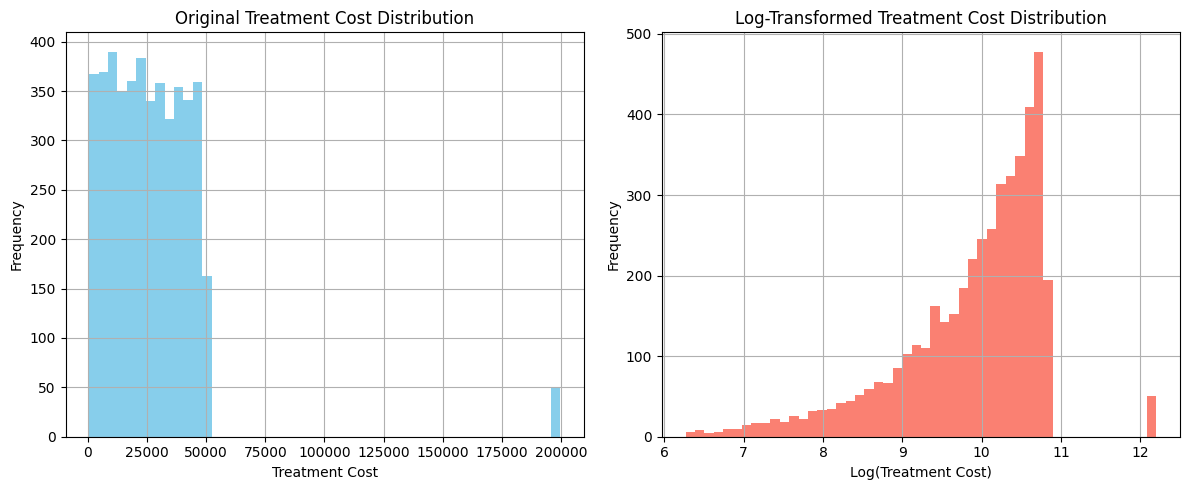

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset (1).csv")

# Step 1: Apply log transformation
# Add a small constant to avoid log(0) errors
df['Treatment_Cost_Log'] = np.log1p(df['Treatment_Cost'])

# Step 2: Compare distributions (before vs after)
plt.figure(figsize=(12,5))

# Original distribution
plt.subplot(1,2,1)
df['Treatment_Cost'].hist(bins=50, color='skyblue')
plt.title("Original Treatment Cost Distribution")
plt.xlabel("Treatment Cost")
plt.ylabel("Frequency")

# Log-transformed distribution
plt.subplot(1,2,2)
df['Treatment_Cost_Log'].hist(bins=50, color='salmon')
plt.title("Log-Transformed Treatment Cost Distribution")
plt.xlabel("Log(Treatment Cost)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [9]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset (1).csv")

# Step 1: Sort data by Admission_Date
df_sorted = df.sort_values(by="Admission_Date")

# Step 2: Apply forward fill (propagate last valid date forward)
df_sorted['Admission_Date_ffill'] = df_sorted['Admission_Date'].fillna(method='ffill')

# Step 3: Apply backward fill (propagate next valid date backward)
df_sorted['Admission_Date_bfill'] = df_sorted['Admission_Date'].fillna(method='bfill')

# Display comparison for rows with missing Admission_Date
print(df_sorted[df_sorted['Admission_Date'].isnull()][['Patient_ID','Admission_Date','Admission_Date_ffill','Admission_Date_bfill']])


Empty DataFrame
Columns: [Patient_ID, Admission_Date, Admission_Date_ffill, Admission_Date_bfill]
Index: []


/tmp/ipykernel_12679/1725655424.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_sorted['Admission_Date_ffill'] = df_sorted['Admission_Date'].fillna(method='ffill')
/tmp/ipykernel_12679/1725655424.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_sorted['Admission_Date_bfill'] = df_sorted['Admission_Date'].fillna(method='bfill')
